In [125]:
import numpy as np
import matplotlib.pyplot as plt

In [126]:

def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])       # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1] -y[i])/h[i] - (y[i]-y[i-1])/h[i-1])             # Right-hand side vector

    return A, B, C, D

In [127]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [128]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S


In [129]:
def generate_spline(x,y):
    A,B,C,D = setup_tridiagonal_matrix(x,y)
    M_1 = thomas_algorithm(A,B,C,D)
    M = np.zeros(len(y))
    M[1:-1] = M_1
    return M

In [130]:
import numpy as np
def least_squares(x,y):
    assert(len(x) == len(y))
    n = len(x)
    
    sum_x = sum(x)
    sum_y = sum(y)
    sum_x2 = sum([x_i**2 for x_i in x])
    sum_xy = sum([x_i * y_i for x_i,y_i in zip(x,y)])
    
    m = (n * sum_xy - (sum_x * sum_y))/((n * sum_x2) - (sum_x)**2)
    c = (sum_y - (m * sum_x))/n
    return m ,c

In [131]:
def create_vandermonde_matrix(x):
    #Degree 4
    mat = np.zeros((len(x),5))
    print(mat.shape)
    for i in range(len(x)):
        for j in range(5):
            mat[i][j] = x[i] ** j
    return mat

In [132]:
def solve_vandermonde_matrix(x,y):
    vander = create_vandermonde_matrix(x_data)

    A = vander.T @ vander
    B = vander.T @ y
    
    return np.linalg.solve(A,B)

In [133]:
gdp = np.array([
    1.9, 3.9, 3.1, 2.1, -0.9, 2.7, -0.1, 4.6, 3.4, 1.8,
    0.6, 0.5, 4.0, 1.1, 3.5, 3.5, -1.4, 5.3, 5.0, 2.0,
    3.6, 2.5, 1.6, 0.7, 2.3, 1.3, 2.9, 2.2, 2.0, 2.3,
    3.2, 4.6, 3.3, 2.1, 2.5, 0.6, 2.5, 3.4, 4.8, 2.8,
    -5.2, -28.0, 34.9, 4.6, 5.7, 7.0, 3.3, 7.0, -1.0, 0.6,
    2.9, 2.8, 2.9, 2.5, 4.7, 3.4
])
x_data = np.arange(1,len(gdp) + 1)

Text(0.5, 1.0, '% GDP Growth in quarters from 2010 Q1 - 2023 Q4')

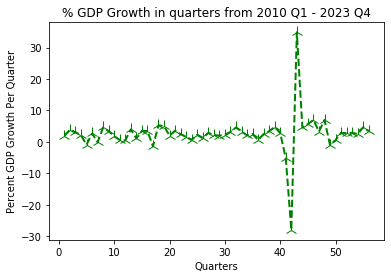

In [134]:
#Part A

M = generate_spline(x_data,gdp)
s = evaluate_spline(x_data,gdp,M,x_data)
plt.plot(x_data, s, color='green', marker='2', linestyle='dashed',
     linewidth=2, markersize=12, label="spline")
plt.xlabel("Quarters")
plt.ylabel("Percent GDP Growth Per Quarter")
plt.title("% GDP Growth in quarters from 2010 Q1 - 2023 Q4")

(56, 5)
(52,)


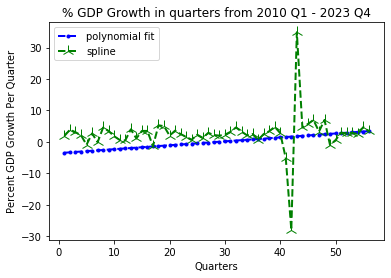

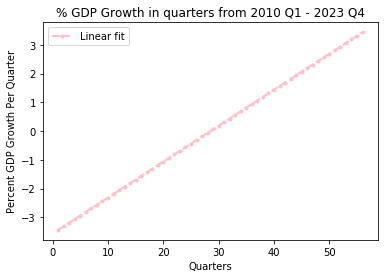

In [139]:
#Part B
x_scaled = (x_data - np.mean(x_data)) / np.std(x_data)
a = solve_vandermonde_matrix(x_scaled,gdp)
y = [np.sum(a * x) for x in x_scaled]

plt.plot(x_data, y, color='blue', marker='o', linestyle='dashed',
     linewidth=2, markersize=3, label="polynomial fit")
plt.plot(x_data, s, color='green', marker='2', linestyle='dashed',
     linewidth=2, markersize=12, label="spline")
plt.xlabel("Quarters")
plt.ylabel("Percent GDP Growth Per Quarter")
plt.title("% GDP Growth in quarters from 2010 Q1 - 2023 Q4")
plt.legend()

x_filtered = np.delete(x_data, np.s_[40:44])
gdp_filtered = np.delete(gdp,np.s_[40:44])
print(x_filtered.shape)

m,c = least_squares(x_filtered,gdp_filtered)
lin_y = (m*x_data) + c
plt.figure()
plt.plot(x_data, y, color='pink', marker='o', linestyle='dashed',
     linewidth=2, markersize=3, label="Linear fit")
plt.xlabel("Quarters")
plt.ylabel("Percent GDP Growth Per Quarter")
plt.title("% GDP Growth in quarters from 2010 Q1 - 2023 Q4")
plt.legend()